# Quickstart — fit a galaxy in one screen

A star-forming galaxy SED, simulated and fitted back, on a laptop, in a
couple of minutes. The forward model is pure JAX, so the likelihood and
its gradient are computed together; NUTS samples directly from the
posterior without hand-tuned proposals.

Two ideas worth pausing on as the model is built:

- `model.summary()` — every assembled piece (SSP, filters, components,
  precomputation) in one block. Glance at this before any fit.
- `tengri.citations` — the bibliography of every physics ingredient,
  collected automatically. Most of a methods section, generated.

Next: [`01_why_jax.py`](01_why_jax.py) on differentiable inference,
[`02_sed_anatomy.py`](02_sed_anatomy.py) on the panchromatic anatomy,
[`03_discovering_the_menu.py`](03_discovering_the_menu.py) on the menu.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    Fitter,
    Observation,
    Photometry,
    SEDModel,
    citations,
    generate_mock,
    load_ssp_data,
    plot,
    recipes,
)

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

W0521 02:24:04.033375 18788104 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


W0521 02:24:07.415192 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:07.422709 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## SSP grid

The Cue nebular emulator used by `recipes.star_forming_photometry()`
requires a **bare-stellar** SSP (no baked-in nebular contribution).
`list_known_ssps()` lists the catalogue; `download_ssp()` fetches on
demand.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

## Photometry

Six SDSS+WISE bands, observed-frame. Wrap the filter set in `Photometry`,
pass it to `Observation` (the projection target of the model).

In [3]:
filters = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wise_w1"]
obs = Observation(photometry=Photometry.from_names(filters))

## Build the model

`recipes.mock_recovery_minimal()` is the cleanest stable starting
point: a truncated-skew-normal SFH, single-knob dust attenuation,
nebular emission off, redshift fixed at 0.05. Five free parameters.
Notebook [`02_sed_anatomy.py`](02_sed_anatomy.py) layers the full
panchromatic physics (nebular, AGN, dust IR, IGM) onto a kitchen-sink
model.

In [4]:
model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    **recipes.mock_recovery_minimal(),
)
print(model.summary())

W0521 02:24:08.223387 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:08.271452 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:08.282532 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
/Users/suchethacooray/.claude-squad/worktrees/cs/otenbokso-udatep_18b118cf202eb770/src/tengri/forward/sed_model.py:836: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To 

W0521 02:24:08.430725 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:08.453367 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:08.694849 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:08.873039 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:09.187714 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:09.411932 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0521 02:24:13.162201 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.231524 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.240767 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.252707 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.266090 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.275118 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.281200 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:13.578921 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.606471 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:13.713703 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:14.110645 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:14.203462 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Model  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     6 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Precomputed: photometry
  Hybrid kernel: active
  Compositional kernel: active
  Components:  igm

  Pipeline (4 components):
    1. stellar        [sfh_model=tsnorm, metallicity_model=delta, n_grid=64]
    2. nebular        [backend=baked_in]
    3. dust           [law_bc=calzetti, law_diff=calzetti]
    4. igm

  Parameters:  7 free
──────────────────────────────────────────────────────────────────


W0521 02:24:14.343517 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Provenance

Every physical ingredient in the model carries its citations through
the registry. `collect_citations` walks the pipeline; the resulting
`Bibliography` exports to a printable list or to BibTeX.

In [5]:
citations.print_citations(model)
# bib_text = citations.citations_bibtex(model)  # → .bib for a manuscript

Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython+{N}um{P}y programs
       code: jax-ml/jax

  [3] Hearin et al. (2023)  —  Differentiable stellar population synthesis engine
       {DSPS: Differentiable stellar population synthesis}
       DOI: 10.1093/mnras/stad456   arXiv: 2112.06830   code: ArgonneCPAC/dsps

  [4] Calzetti et al. (2000)  —  Starburst dust attenuation law
       {The Dust Content and Opacity of Actively Star-forming Galaxies}
       DOI: 10.1086/308692   arXiv: astro-ph/9911459



## Mock galaxy

Sample one set of parameters from the prior; this is the "truth" we will
try to recover. `generate_mock` returns true fluxes, Gaussian
uncertainties at the requested SNR, and a noisy realisation.

In [6]:
key = jax.random.PRNGKey(7)
key_truth, key_mock, key_fit = jax.random.split(key, 3)

truth = model.spec.sample(key_truth)
mock = generate_mock(model, truth, key=key_mock, snr=30.0)
flux_obs = mock["flux_obs"]
noise = mock["noise"]

W0521 02:24:15.324048 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:15.489809 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:16.335643 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:16.593806 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:24:17.026547 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Fit

NUTS samples the posterior using the model gradient. `Fitter` selects a
χ² photometric likelihood by inspecting `obs`. `tengri.lean()` is the
default cache mode and drops the JIT engine after the fit.

In [7]:
fitter = Fitter(model, flux_obs, noise, data_type="photometry")
posterior = fitter.run(
    method="mcmc_nuts",
    key=key_fit,
    n_warmup=400,
    n_samples=400,
)
posterior.summary()

  MAP initialization (200 steps)...


W0521 02:24:31.991466 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:24:32.043980 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:50:30.601693 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:50:30.697586 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:50:30.829273 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:50:30.877955 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  MAP init done (loss=1.83)


W0521 02:50:32.773358 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Posterior  method: NUTS (BlackJAX)  samples: 400  wall_time: 10.7s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_bc                     0.2376    0.1546    0.2951       —
  dust_tau_diff                   1.5000    1.5000    1.5000       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -1.1727   -1.1922   -1.1233       —
  noise_dof                       0.0000    0.0000    0.0000       —
  noise_frac_cal                  0.0000

## Hero figure — posterior SED and SFH

Top: the panchromatic SED with the posterior median, 68 % credible band,
truth (dashed), and the six observed photometry points. Bottom: the
inferred SFH against the truth.

W0521 02:50:49.509651 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:51:01.732032 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:51:04.194199 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 02:51:16.992471 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 02:51:17.021946 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:05:14.304420 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:14.308850 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:14.313159 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:14.491294 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0521 03:05:15.838777 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:15.866386 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:15.973855 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:05:16.046219 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.113950 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.247217 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:05:16.270238 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.344363 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0521 03:05:16.551793 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.555925 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.560396 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.564292 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.650754 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.655021 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.658419 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:16.661628 18787860 pjrt_executable.cc:638] 

W0521 03:05:25.306951 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0521 03:05:25.347864 18787860 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


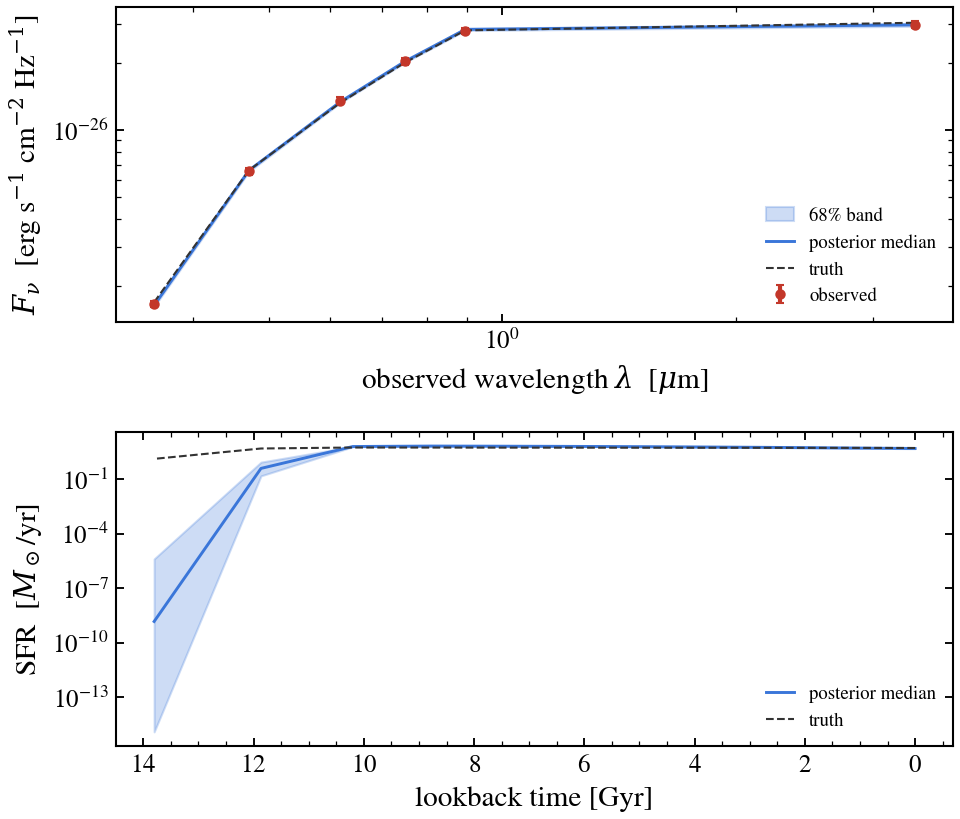

In [8]:
draw_batch = posterior.resample(jax.random.PRNGKey(11), n=200)
phot_draws = np.asarray(jax.vmap(lambda p: model.predict_observables(p).phot_fnu)(draw_batch))
phot = obs.photometry
wave_eff = (
    np.array(
        [
            np.trapezoid(w * t, w) / np.trapezoid(t, w)
            for w, t in zip(phot.filter_waves, phot.filter_trans)
        ]
    )
    / 1e4
)  # μm, transmission-weighted mean per band

fig = plt.figure(figsize=(7.2, 6.4))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.35)
ax_sed = fig.add_subplot(gs[0])
ax_sfh = fig.add_subplot(gs[1])

# SED panel
flux_lo, flux_med, flux_hi = np.percentile(phot_draws, [16, 50, 84], axis=0)
ax_sed.fill_between(wave_eff, flux_lo, flux_hi, color="#3a76d9", alpha=0.25, label="68% band")
ax_sed.plot(wave_eff, flux_med, color="#3a76d9", lw=1.4, label="posterior median")
ax_sed.plot(wave_eff, np.asarray(mock["flux_true"]), color="0.2", lw=1.0, ls="--", label="truth")
ax_sed.errorbar(
    wave_eff,
    np.asarray(flux_obs),
    yerr=np.asarray(noise),
    fmt="o",
    color="#c3372a",
    ms=4,
    capsize=2,
    label="observed",
)
ax_sed.set_xscale("log")
ax_sed.set_yscale("log")
ax_sed.set_xlabel(r"observed wavelength $\lambda$  [$\mu$m]")
ax_sed.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sed.legend(frameon=False, fontsize=9, loc="best")


# SFH panel — SFH history lives in the orchestrator state, not the
# Prediction wrapper (which only exposes scalar derived quantities).
def _sfh(p_dict):
    s = model.predict_state(p_dict)
    return (np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9, np.asarray(s.derived["sfr_history"]))


sfr_draws, lbt = [], None
fixed = model.spec.get_fixed_values()
for i in range(80):
    p = {k: float(v[i]) for k, v in draw_batch.items()}
    p = {**fixed, **p}
    lbt_i, sfr_i = _sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color="#3a76d9", alpha=0.25)
ax_sfh.plot(lbt, sfr_med, color="#3a76d9", lw=1.4, label="posterior median")
lbt_t, sfr_t = _sfh({**fixed, **truth})
ax_sfh.plot(lbt_t, sfr_t, color="0.2", ls="--", lw=1.0, label="truth")
ax_sfh.set_yscale("log")
ax_sfh.invert_xaxis()
ax_sfh.set_xlabel("lookback time [Gyr]")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$/yr]")
ax_sfh.legend(frameon=False, fontsize=9)
fig.savefig(FIG_DIR / "00_posterior_sed_sfh.png", dpi=300, bbox_inches="tight")

## Posterior corner

The physically meaningful free parameters — stellar mass, current SFR,
birth-cloud τ, and redshift — are well constrained from six bands plus
IR coverage. Wider tails appear on the SFH shape parameters, which is
expected.

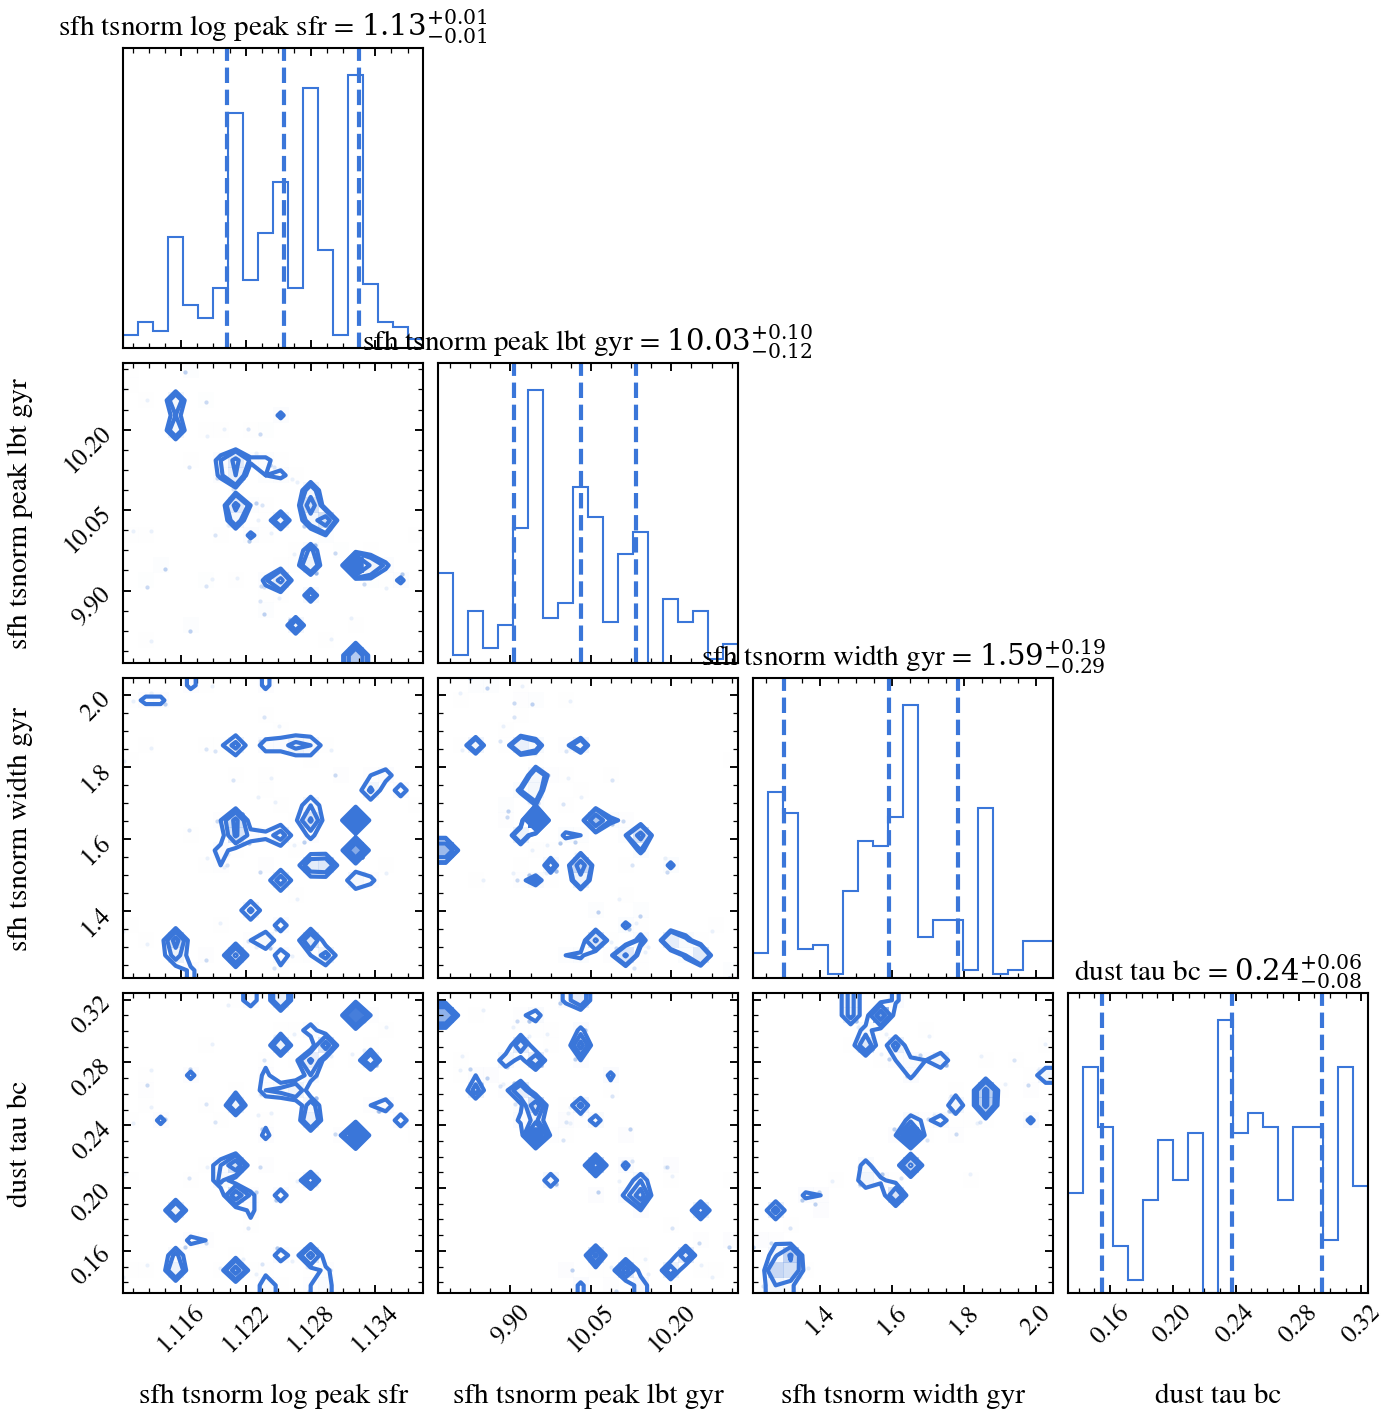

In [9]:
import corner

sampled = list(posterior.samples.keys())
prefer = [
    "sfh_tsnorm_log_peak_sfr",
    "sfh_tsnorm_peak_lbt_gyr",
    "sfh_tsnorm_width_gyr",
    "dust_tau_bc",
    "sfh_dpl_log_peak_sfr",
    "sfh_dpl_alpha",
    "redshift",
]
# Keep only params with non-trivial dynamic range (a stuck chain or
# tightly-pinned param breaks corner.corner otherwise).
corner_params = []
for p in prefer:
    if p not in sampled:
        continue
    s = np.asarray(posterior.samples[p])
    if s.std() > 1e-6 * (np.abs(s.mean()) + 1e-9):
        corner_params.append(p)
corner_params = corner_params[:5]
samples_arr = np.column_stack([np.asarray(posterior.samples[k]) for k in corner_params])
truths_arr = [float(truth[k]) if k in truth else None for k in corner_params]
fig_corner = corner.corner(
    samples_arr,
    labels=[k.replace("sfh_dpl_", "").replace("_", " ") for k in corner_params],
    truths=truths_arr,
    color="#3a76d9",
    truth_color="0.2",
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")